# Phase 1 — agreement studies (working notebook)

Foundations for the Phase 1 write-up (`docs/phase1-design.md`): the effectiveness gate,
the RQ1 lexical agreement profiles, the gap-gradient validity control, the joint fit,
and the RQ2 WordNet-tier semantic axioms. The grid is complete as of 2026-07-12; decisions are
recorded in `docs/phase1-design.md` §9.

**Grid**: {DL19, DL20} × {top-10 all-pairs (*primary*), uniform depth-100 (*validity
control*)} × {Qwen 3.6 35B (primary, prompt v1), Flan-T5-large (contrast, v0)}.
All axiom preferences below postdate the 2026-07-11 `ir_axioms` PROX fixes
(PROX2 sign flip, PROX1 determinism) — unlike the Phase 0 pilot numbers.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from axiomrank.paths import results_dir

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
PRIMARY = "models/qwen3.6-35B-A3B-AWQ"
CONTRAST = "google/flan-t5-large"
MODEL_COLOR = {PRIMARY: "#2a78d6", CONTRAST: "#1baf7a"}
MODEL_LABEL = {PRIMARY: "Qwen 3.6 35B", CONTRAST: "Flan-T5-large"}
COND_COLOR = {"top10": "#2a78d6", "uniform": "#4a3aa7"}
CELLS = ["dl19_top10", "dl19_uniform", "dl20_top10", "dl20_uniform"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.edgecolor": BASE, "font.size": 11,
})


def load_cells(experiment: str, filename: str) -> dict:
    """{(cell, model): DataFrame|dict} for every grid cell that has `filename`."""
    out = {}
    for path in sorted(results_dir(experiment).glob(f"dl*/metrics/*/{filename}")):
        cell, _, model_dir = path.relative_to(results_dir(experiment)).parts[:3]
        model = model_dir.replace("__", "/")
        out[(cell, model)] = (
            pd.read_csv(path) if filename.endswith(".csv") else json.loads(path.read_text())
        )
    return out


rq1 = load_cells("rq1_lexical_agreement", "agreement.csv")
rq1_gap = load_cells("rq1_lexical_agreement", "gap_agreement.csv")
rq1_fit = load_cells("rq1_lexical_agreement", "joint_fit.json")
rq2 = load_cells("rq2_semantic_agreement", "agreement.csv")
rq2_fit = load_cells("rq2_semantic_agreement", "joint_fit.json")
eff = load_cells("ranking_effectiveness", "effectiveness.json")

status = pd.DataFrame(
    {
        f"{label} · {MODEL_LABEL[m]}": {
            cell: "✓" if (cell, m) in data else "—" for cell in CELLS
        }
        for label, data in [("RQ1", rq1), ("RQ2", rq2), ("gate", eff)]
        for m in [PRIMARY, CONTRAST]
    }
)
status  # gate is only defined on the top-10 condition

,RQ1 · Qwen 3.6 35B,RQ1 · Flan-T5-large,RQ2 · Qwen 3.6 35B,RQ2 · Flan-T5-large,gate · Qwen 3.6 35B,gate · Flan-T5-large
dl19_top10,✓,✓,✓,✓,✓,✓
dl19_uniform,✓,✓,—,—,—,—
dl20_top10,✓,✓,✓,✓,✓,✓
dl20_uniform,✓,✓,—,—,—,—


## 1. Effectiveness gate — the top-10 residual is skill

Copeland aggregation of the cached pairwise verdicts (= PRP-allpair) vs the BM25
first-stage run, nDCG@10 against TREC qrels. **Gate: Qwen must clearly beat BM25 on
both collections** (design §4); Flan-T5 is contrast only.

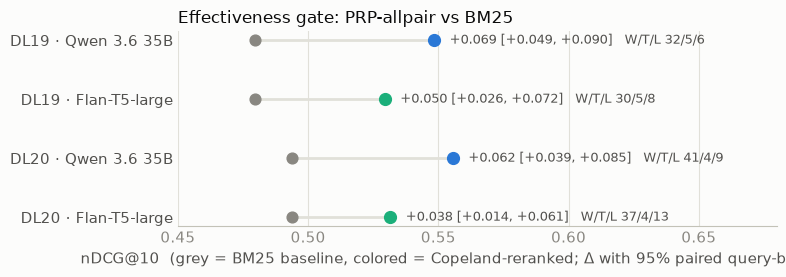

bm25  reranked  delta  ci_lo  ci_hi  \
collection model                                                              
DL19       models/qwen3.6-35B-A3B-AWQ  0.480     0.548  0.069  0.049  0.090   
           google/flan-t5-large        0.480     0.529  0.050  0.026  0.072   
DL20       models/qwen3.6-35B-A3B-AWQ  0.494     0.556  0.062  0.039  0.085   
           google/flan-t5-large        0.494     0.531  0.038  0.014  0.061   

                                           wtl  
collection model                                
DL19       models/qwen3.6-35B-A3B-AWQ   32/5/6  
           google/flan-t5-large         30/5/8  
DL20       models/qwen3.6-35B-A3B-AWQ   41/4/9  
           google/flan-t5-large        37/4/13

In [2]:
eff_perq = load_cells("ranking_effectiveness", "effectiveness.csv")

rng = np.random.default_rng(0)
rows = []
for (cell, model), e in sorted(eff.items()):
    m = e["metrics"]["nDCG@10"]
    d = eff_perq[(cell, model)]["nDCG@10_delta"].to_numpy()
    boot = rng.choice(d, size=(10_000, d.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    rows.append({
        "collection": cell.split("_")[0].upper(), "model": model,
        "bm25": m["mean_baseline"], "reranked": m["mean_reranked"],
        "delta": m["mean_delta"], "ci_lo": lo, "ci_hi": hi,
        "wtl": f'{m["wins"]}/{m["ties"]}/{m["losses"]}',
    })
gate = pd.DataFrame(rows).sort_values(["collection", "model"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(8, 2.9))
for y, r in enumerate(gate.itertuples()):
    ax.plot([r.bm25, r.reranked], [y, y], color=GRID, linewidth=2, zorder=1)
    ax.scatter(r.bm25, y, s=60, color=MUTED, zorder=2)
    ax.scatter(r.reranked, y, s=72, color=MODEL_COLOR[r.model], zorder=3)
    ax.text(r.reranked + 0.006, y,
            f"+{r.delta:.3f} [{r.ci_lo:+.3f}, {r.ci_hi:+.3f}]   W/T/L {r.wtl}",
            va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(gate)),
              [f"{r.collection} · {MODEL_LABEL[r.model]}" for r in gate.itertuples()])
ax.invert_yaxis()
ax.set_xlim(0.45, 0.68)
ax.set_xlabel("nDCG@10  (grey = BM25 baseline, colored = Copeland-reranked; "
              "Δ with 95% paired query-bootstrap CI)")
ax.set_title("Effectiveness gate: PRP-allpair vs BM25", loc="left", fontsize=12)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

gate.set_index(["collection", "model"]).round(3)

**Gate passed.** Qwen beats BM25 by +0.069 (DL19) and +0.062 (DL20) nDCG@10, with
lopsided win/loss counts (32/6, 41/9) and 95% paired query-bootstrap CIs entirely
above zero for every cell — the residual Phase 1 studies is genuine reranking skill.
Flan-T5 also clears BM25 (pairwise aggregation is forgiving of a noisy judge) but
trails Qwen everywhere. Reranked ≈ 0.55 sits below the ≈ 0.65 literature anchor for
strong PRP rerankers, consistent with position consistency of only 0.71/0.74
collapsing a quarter of the pairs to ties — worth a sentence in the write-up, not a
gate failure.

## 2. RQ1 — per-axiom agreement profiles (Qwen)

Agreement with the judge where the axiom fires and the judge is decisive, with
query-bootstrap 95% CIs. Blue = top-10 all-pairs (primary), violet = uniform
depth-100 control. TFC3 and M-TDC are omitted (they fire on < 15 pairs per cell);
relaxed-precondition variants are in §5.

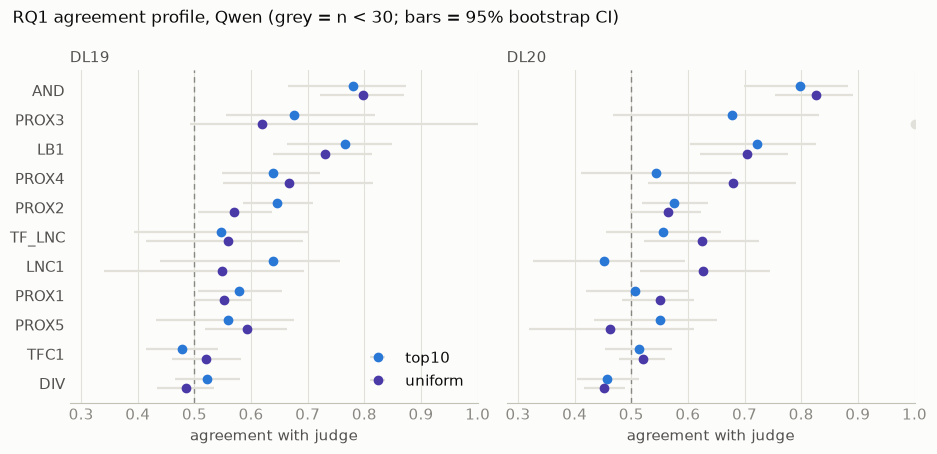

In [3]:
MIN_N = 30
base = [a for a in rq1[("dl19_top10", PRIMARY)].axiom
        if "@" not in a and a not in ("TFC3", "M_TDC")]
order = (pd.concat([rq1[(c, PRIMARY)].set_index("axiom").agreement for c in CELLS
                    if (c, PRIMARY) in rq1], axis=1)
         .loc[base].mean(axis=1).sort_values().index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6), sharey=True)
for ax, coll in zip(axes, ["dl19", "dl20"]):
    ax.axvline(0.5, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    for cond, dy in [("top10", 0.16), ("uniform", -0.16)]:
        key = (f"{coll}_{cond}", PRIMARY)
        if key not in rq1:
            continue
        df = rq1[key].set_index("axiom").loc[order]
        ok = df.n_evaluable >= MIN_N
        y = [order.index(a) + dy for a in df.index]
        ax.errorbar(df.agreement[ok], [v for v, k in zip(y, ok) if k],
                    xerr=[(df.agreement - df.ci_lo)[ok], (df.ci_hi - df.agreement)[ok]],
                    fmt="o", ms=6, color=COND_COLOR[cond], ecolor=GRID,
                    elinewidth=1.6, capsize=0, label=cond, zorder=3)
        ax.scatter(df.agreement[~ok], [v for v, k in zip(y, ok) if not k],
                   s=36, color=GRID, zorder=2)
    ax.set_title(coll.upper(), loc="left", fontsize=11, color=INK2)
    ax.set_xlim(0.28, 1.0)
    ax.set_xlabel("agreement with judge")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
axes[0].set_yticks(range(len(order)), order)
axes[0].legend(loc="lower right", frameon=False, title=None)
fig.suptitle("RQ1 agreement profile, Qwen (grey = n < 30; bars = 95% bootstrap CI)",
             x=0.02, ha="left", fontsize=12)
plt.tight_layout()
plt.show()

The profile is consistent across collections: the best-aligned axioms are the
document-structure ones — **AND (~0.65–0.80) and LB1 (~0.73–0.77)** — not the classic
TF core. **TFC1 sits at chance** in every cell (top-10 *and* uniform), and **DIV is at
or below chance** despite firing on > 90% of pairs. The proximity family lands in
between (~0.55–0.68). Note the CIs: with 43–54 queries most axioms' intervals span
±0.05–0.10, so small cross-cell differences should not be over-read.

## 3. Gap gradient — the validity control

Design §2.3 expects agreement near chance on adjacent-rank pairs, rising with BM25
rank gap. Uniform cells, Qwen; x = upper edge of the gap decile.

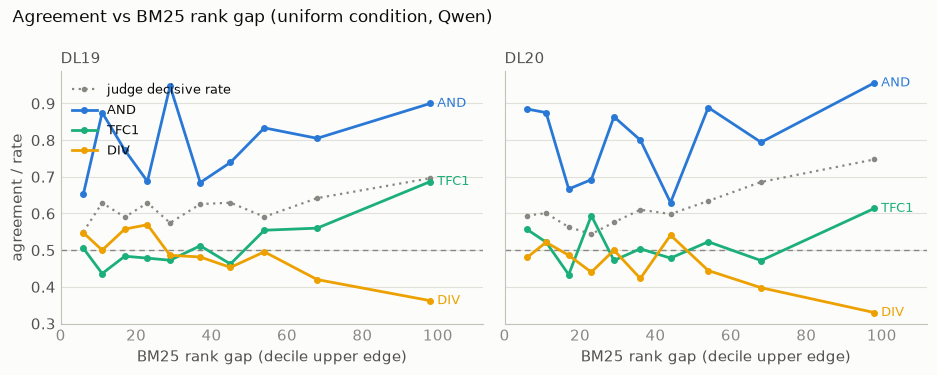

In [4]:
series = [("AND", "#2a78d6"), ("TFC1", "#1baf7a"), ("DIV", "#eda100")]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)
for ax, coll in zip(axes, ["dl19", "dl20"]):
    key = (f"{coll}_uniform", PRIMARY)
    if key not in rq1_gap:
        ax.set_axis_off()
        continue
    g = rq1_gap[key]
    bins = g.groupby("gap_bin")[["decisive_rate"]].first()
    ax.axhline(0.5, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    ax.plot(bins.index, bins.decisive_rate, color=MUTED, linewidth=1.6,
            linestyle=(0, (1, 2)), marker=".", label="judge decisive rate")
    for name, c in series:
        s = g[g.axiom == name].set_index("gap_bin").agreement
        ax.plot(s.index, s, color=c, linewidth=2, marker="o", ms=4, label=name)
        ax.annotate(name, (s.index[-1], s.iloc[-1]), xytext=(5, 0),
                    textcoords="offset points", color=c, fontsize=9.5, va="center")
    ax.set_title(coll.upper(), loc="left", fontsize=11, color=INK2)
    ax.set_xlabel("BM25 rank gap (decile upper edge)")
    ax.set_xlim(0, 112)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
axes[0].set_ylabel("agreement / rate")
axes[0].legend(loc="upper left", frameon=False, fontsize=9)
fig.suptitle("Agreement vs BM25 rank gap (uniform condition, Qwen)",
             x=0.02, ha="left", fontsize=12)
plt.tight_layout()
plt.show()

The gradient is **weaker than the design expected**. The judge's decisive rate rises
cleanly with gap (~0.55 → ~0.70–0.75), and TFC1 climbs only in the widest deciles
(~0.6–0.7 at gap ≈ 100). But there is no broad "classical axioms visibly work on
wide-gap pairs" regime: AND is high at *every* gap, and DIV drifts **below** chance as
the gap widens (0.55 → 0.33–0.36) — on easy pairs the judge systematically prefers the
document DIV penalises. Design §2.3 says a missing gradient is a finding to chase
before RQ3, not to skip; this needs its own look (per-axiom gradients + CIs).

## 4. Joint fit — how much of the judge do the axioms explain?

Query-grouped 5-fold CV logistic regression on decisive pairs: strict core (10
classical axioms) vs full battery (+ AND/DIV/LB1 + relaxed variants). Baseline is the
majority class rate.

,base rate,strict core,full battery,AUC (full),n pairs
cell,,,,,
dl19_top10,0.573,0.591,0.639,0.670,1356
dl19_uniform,0.522,0.540,0.569,0.629,1297
dl20_top10,0.548,0.547,0.592,0.633,1802
dl20_uniform,0.507,0.511,0.601,0.653,1660


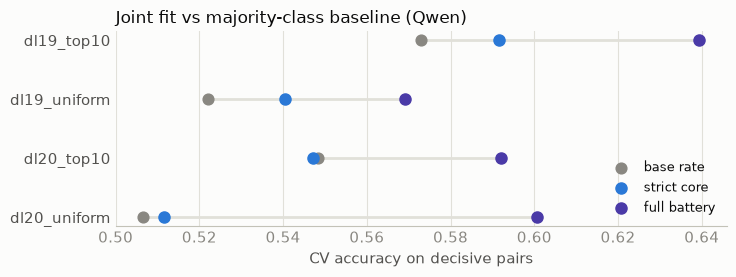

In [5]:
rows = []
for cell in CELLS:
    if (cell, PRIMARY) not in rq1_fit:
        continue
    jf = rq1_fit[(cell, PRIMARY)]
    rows.append({
        "cell": cell,
        "base rate": jf["strict_core"]["base_rate"],
        "strict core": jf["strict_core"]["cv_accuracy"],
        "full battery": jf["full_battery"]["cv_accuracy"],
        "AUC (full)": jf["full_battery"]["cv_auc"],
        "n pairs": jf["strict_core"]["n_decisive_pairs"],
    })
fit = pd.DataFrame(rows).set_index("cell")

fig, ax = plt.subplots(figsize=(7.5, 2.9))
for y, (cell, r) in enumerate(fit.iterrows()):
    ax.plot([r["base rate"], r["full battery"]], [y, y], color=GRID, lw=2, zorder=1)
    ax.scatter(r["base rate"], y, s=60, color=MUTED, zorder=2, label="base rate" if y == 0 else None)
    ax.scatter(r["strict core"], y, s=64, color="#2a78d6", zorder=3, label="strict core" if y == 0 else None)
    ax.scatter(r["full battery"], y, s=64, color="#4a3aa7", zorder=3, label="full battery" if y == 0 else None)
ax.set_yticks(range(len(fit)), fit.index)
ax.invert_yaxis()
ax.set_xlabel("CV accuracy on decisive pairs")
ax.set_title("Joint fit vs majority-class baseline (Qwen)", loc="left", fontsize=12)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)
ax.legend(loc="lower right", frameon=False, fontsize=9)
plt.tight_layout()
fit.round(3)

The strict Phase 0 core is nearly uninformative on its own: +0–2 accuracy points
over the majority-class base rate (on DL20 top-10, nothing at all). The additions do
the work — the full battery reaches 0.57–0.64 CV accuracy (AUC 0.63–0.67), +4–9
points over base, with AND/LB1/DIV carrying most of the gain. That is RQ3's starting
number: roughly 60% of decisive verdicts explained, 40% residual.

## 5. Relaxed preconditions — coverage vs agreement

Design §5.2: margin-relaxed variants of the strict-precondition axioms
(LNC1@tf{0.2,0.5}, TF-LNC@len{0.1,0.3}, M-TDC@mass{0.1,0.3}; TFC1/TFC3 relax the
shared LEN margin to {0.2,0.5}). The design's key question: does M-TDC's Phase 0
agreement (0.83–0.89 on a 15-pair niche) survive the coverage gain?

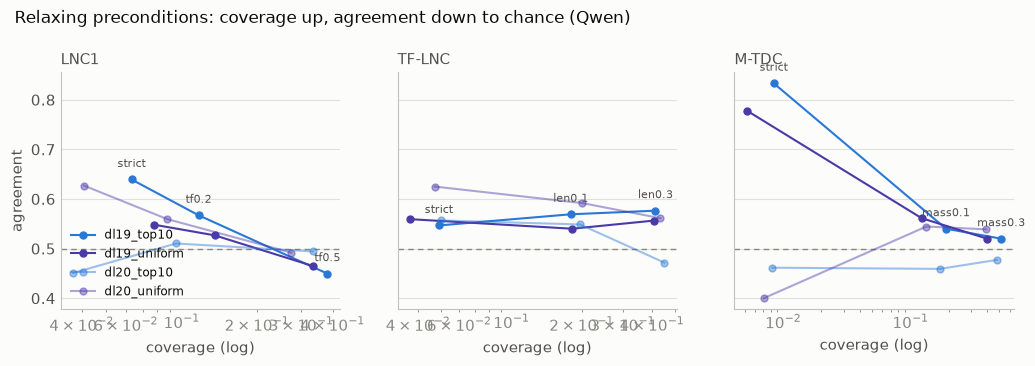

,dl19_top10,dl19_uniform,dl20_top10,dl20_uniform
agreement (n evaluable),,,,
LNC1,0.639 (61),0.548 (62),0.451 (51),0.627 (59)
LNC1@tf0.2,0.567 (134),0.527 (131),0.510 (145),0.559 (118)
LNC1@tf0.5,0.450 (496),0.465 (374),0.494 (532),0.492 (366)
TF_LNC,0.547 (75),0.559 (59),0.557 (88),0.625 (72)
TF_LNC@len0.1,0.569 (253),0.540 (237),0.549 (339),0.592 (338)
TF_LNC@len0.3,0.576 (569),0.557 (548),0.472 (799),0.561 (750)
M_TDC,0.833 (12),0.778 (9),0.462 (13),0.400 (5)
M_TDC@mass0.1,0.540 (274),0.561 (171),0.459 (294),0.545 (202)
M_TDC@mass0.3,0.520 (725),0.520 (554),0.477 (855),0.539 (644)


In [6]:
FAMILIES = {
    "LNC1": ["LNC1", "LNC1@tf0.2", "LNC1@tf0.5"],
    "TF-LNC": ["TF_LNC", "TF_LNC@len0.1", "TF_LNC@len0.3"],
    "M-TDC": ["M_TDC", "M_TDC@mass0.1", "M_TDC@mass0.3"],
}

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.7), sharey=True)
for ax, (fam, members) in zip(axes, FAMILIES.items()):
    ax.axhline(0.5, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    for cell in CELLS:
        df = rq1[(cell, PRIMARY)].set_index("axiom").loc[members]
        cond = "top10" if cell.endswith("top10") else "uniform"
        ax.plot(df.coverage, df.agreement, marker="o", ms=5,
                color=COND_COLOR[cond],
                alpha=1.0 if cell.startswith("dl19") else 0.45,
                label=cell if fam == "LNC1" else None)
    df = rq1[("dl19_top10", PRIMARY)].set_index("axiom").loc[members]
    for name, cov, agr in zip(members, df.coverage, df.agreement):
        ax.annotate(name.split("@")[1] if "@" in name else "strict", (cov, agr),
                    xytext=(0, 9), textcoords="offset points", ha="center",
                    fontsize=8, color=INK2)
    ax.set_xscale("log")
    ax.set_title(fam, loc="left", fontsize=11, color=INK2)
    ax.set_xlabel("coverage (log)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
axes[0].set_ylabel("agreement")
axes[0].legend(loc="lower left", frameon=False, fontsize=8.5)
fig.suptitle("Relaxing preconditions: coverage up, agreement down to chance (Qwen)",
             x=0.02, ha="left", fontsize=12)
plt.tight_layout()
plt.show()

rel = [a for members in FAMILIES.values() for a in members] + [
    "TFC1", "TFC1@len0.2", "TFC1@len0.5"]
pd.DataFrame({
    cell: rq1[(cell, PRIMARY)].set_index("axiom").loc[rel]
          .apply(lambda r: f"{r.agreement:.3f} ({int(r.n_evaluable)})", axis=1)
    for cell in CELLS
}).rename_axis("agreement (n evaluable)")

**Relaxation buys coverage, not agreement — the answer to the design's key question
is no.** M-TDC's strict 0.83 (12 pairs, DL19) collapses to 0.52–0.56 once the
single-difference gate is dropped (274–855 pairs), and on DL20 even the strict
variant is at chance: the Phase 0 number was a small-sample artefact of its niche.
LNC1 decays toward and below chance as the TF margin widens; TF-LNC's relaxations sit at a weak
0.47–0.59. Two levers are degenerate: TFC1@len is bit-for-bit identical to
strict TFC1 (the LEN margin never binds on these pools), and TFC3 stays dead (≤ 4
evaluable pairs) at every margin — document-length equality was never its binding
precondition. No relaxed variant earns a headline place on agreement; they stay in
the feature set only for the joint fit above, where the regularised CV can still use
weak or anti signals.

## 6. RQ2 — do WordNet-tier semantic axioms add anything?

STMC1/STMC2/REG/ANTI-REG with the WordNet similarity backend, and the design §2.5
question: does adding them to the lexical battery improve the joint fit?

In [7]:
sem = pd.concat({cell: rq2[(cell, PRIMARY)].set_index("axiom").loc[
                     lambda d: d.index.str.endswith("@wn"),
                     ["coverage", "n_evaluable", "agreement", "ci_lo", "ci_hi"]]
                 for cell in CELLS if (cell, PRIMARY) in rq2}, names=["cell"])
display(sem.round(3))

delta = pd.DataFrame({
    cell: {
        "lexical cv_acc": jf["lexical"]["cv_accuracy"],
        "combined cv_acc": jf["combined"]["cv_accuracy"],
        "Δ accuracy": jf["combined"]["cv_accuracy"] - jf["lexical"]["cv_accuracy"],
        "Δ AUC": jf["combined"]["cv_auc"] - jf["lexical"]["cv_auc"],
    }
    for cell in CELLS if (cell, PRIMARY) in (locals().get("rq2_fit") or rq2_fit)
    for jf in [rq2_fit[(cell, PRIMARY)]]
}).T
delta.round(3)

coverage  n_evaluable  agreement  ci_lo  ci_hi
cell       axiom                                                      
dl19_top10 STMC1@wn        0.967         1330      0.546  0.488  0.600
           STMC2@wn        0.077          110      0.555  0.426  0.681
           REG@wn          0.716          993      0.502  0.427  0.575
           ANTI_REG@wn     0.619          858      0.556  0.471  0.634
dl20_top10 STMC1@wn        0.960         1734      0.519  0.473  0.564
           STMC2@wn        0.094          167      0.509  0.405  0.615
           REG@wn          0.732         1342      0.489  0.419  0.557
           ANTI_REG@wn     0.641         1158      0.505  0.448  0.563

,lexical cv_acc,combined cv_acc,Δ accuracy,Δ AUC
dl19_top10,0.641,0.625,-0.016,-0.017
dl20_top10,0.592,0.580,-0.012,-0.016


**fastText go/no-go (design §6.1): no-go.** The per-axiom trigger nominally fires
twice on DL19 (STMC2@wn 0.555 at coverage 0.077; ANTI-REG@wn 0.556 at 0.619), but
neither replicates on DL20 (0.509 / 0.505), every semantic CI spans 0.5, and the
joint-fit criterion points the other way: adding the WordNet semantics *lowers* CV
accuracy and AUC in all four cells (Δacc −0.7 to −1.6 points). A blunt similarity
that moves nothing does not justify the 7.24 GB sharper one; the RQ2 answer is a
null, with the WordNet-crudeness caveat (design §8) stated alongside.

## Takeaways

1. **Gate passed** — Qwen +0.069/+0.062 nDCG@10 over BM25 (DL19/DL20), bootstrap CIs
   entirely above zero; the top-10 residual is skill and every downstream analysis is
   licensed.
2. **The headline null replicates on DL20** (profile correlation r ≈ 0.79–0.86 across
   collections, r = 0.93 across models on DL20): the classical TF core explains almost
   nothing (TFC1 at chance everywhere); the alignment that *does* exist lives in
   AND (0.78–0.83) / LB1 (0.70–0.77) and, more weakly, proximity.
3. **The gap gradient did not appear as designed** — judge decisiveness rises with gap
   but per-axiom agreement mostly doesn't, and DIV inverts (0.55 → 0.33). This is the
   "finding to chase before RQ3".
4. **Relaxed preconditions buy coverage, not agreement** — M-TDC's celebrated 0.83 was
   a 12-pair artefact; no relaxed variant is a headline axiom.
5. **WordNet semantics add no predictive power** (combined < lexical in all four
   cells) → **fastText no-go**; RQ2's answer is a defensible null.
6. **Joint fit**: full battery reaches 0.57–0.64 CV accuracy (AUC 0.63–0.67) vs base
   rates 0.51–0.57 — RQ3's starting number.

Decisions (RQ3 feature set, WordNet-only backend, pooled collections, top-10 cells)
are recorded in `docs/phase1-design.md` §9.

**Open items carried into RQ3**
- The gap-gradient anomaly: per-axiom gradients with CIs, and why DIV inverts on
  wide-gap pairs.
- When pooling DL19+DL20, report per-collection numbers as robustness checks
  (design §9 decision 3).